### `6b Fill and Resample the DEMs using GDAL`

Notebook contents 
* taking the DEM's created in `6a_load_clip_arctic_dem.ipynb` and filling the nan's with GDAL, then resampling the resolution, and resaving 

created by Cassie Lumbrazo\
last updated: July 2025\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

from rasterio.warp import transform_bounds

In [2]:
from scipy import ndimage

from rasterio.fill import fillnodata

from osgeo import gdal # installed gdal into `rasterio` conda env
import shutil
from pyproj import Transformer

In [3]:
pwd

'/home/cassie/python/repos/juneau_data_analysis'

# Wind Ninja Input Data Required, 
* an elevation data file for the modeling area 
* a domain-averaged input wind speed and direction, and
* a specification of the dominant vegetation in the area 

### Open the Clipped DEM from `6_load_arctic_dem.ipynb`

In [4]:
input_path = '/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch.tif'

# open the DEM 
dem = rioxarray.open_rasterio(input_path, masked=True)
dem

<xarray.DataArray (band: 1, y: 3928, x: 4364)> Size: 69MB
[17141792 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 35kB 5.238e+05 5.238e+05 ... 5.325e+05 5.325e+05
  * y            (y) float64 31kB 6.463e+06 6.463e+06 ... 6.455e+06 6.455e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

New Wind Ninja error with the DEM, 

"The input dataset contains pixels with no data. These datasets cannot be used by Wind Ninja, would you like to attempt to fill those pixels?"

In [5]:
# check the dem for missing data
print("total pixels:", dem.sum().values)
print("# that are nan:", dem.isnull().sum().values)

total pixels: 9023617000.0
# that are nan: 3928


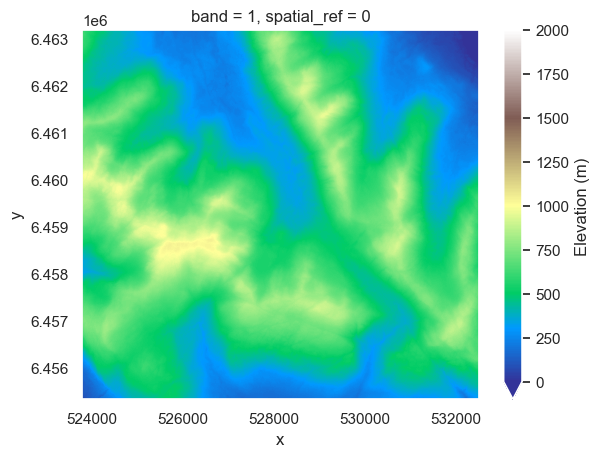

In [6]:
dem.squeeze().plot(cmap='terrain', vmin=0, vmax=2000, cbar_kwargs={'label': 'Elevation (m)'})

## Fill Missing Data 
#### Starting with Methods 1: Interpolation with `scipy.ndimage` which is good for small holes or edges with nans 

In [7]:
# # Load your DEM
# dem_fill = rxr.open_rasterio("your_dem.tif", masked=True).squeeze()
dem_fill = dem.squeeze()

# Check for missing data
nodata_mask = np.isnan(dem_fill)

# Fill missing data with nearest neighbor
filled = dem_fill.copy()
filled.data[nodata_mask] = ndimage.generic_filter(
    dem_fill.data,
    function=lambda x: np.nanmean(x),
    size=5,  # 5x5 neighborhood
    mode='mirror'
)[nodata_mask]

# Replace DEM data
dem_fill.data = filled

# Save the filled DEM
dem_fill.rio.to_raster("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch_filled_ndimage.tif")

In [8]:
# check for missing data now that we filled everything... 
print("total pixels in the OG:", dem.sum().values)
print("# that are nan without filling:", dem.isnull().sum().values)
print("# that are nan with    filling:", dem_fill.isnull().sum().values)

total pixels in the OG: 9023617000.0
# that are nan without filling: 3928
# that are nan with    filling: 0


So, that worked out nicely. It did take 3 minutes... 

So perhaps in the future we would want another method? Below is an option commented out, and then below that, I will try a version with rasterio, then move on for now. 

Since the iterative fill is taking so long to run, let's try a faster option...

Commenting this block of code out for now, because I am not going to use it... let's see if we need it in the future 

In [9]:
# def smart_fill_nans(data, max_iter=50):
#     filled = data.copy()
#     for _ in range(max_iter):
#         nan_mask = np.isnan(filled)
#         if not np.any(nan_mask):
#             break

#         # Get 4-neighbor average but only for NaNs
#         neighbors_sum = (
#             np.roll(filled, 1, axis=0) +
#             np.roll(filled, -1, axis=0) +
#             np.roll(filled, 1, axis=1) +
#             np.roll(filled, -1, axis=1)
#         )

#         neighbors_count = (
#             (~np.isnan(np.roll(filled, 1, axis=0))).astype(int) +
#             (~np.isnan(np.roll(filled, -1, axis=0))).astype(int) +
#             (~np.isnan(np.roll(filled, 1, axis=1))).astype(int) +
#             (~np.isnan(np.roll(filled, -1, axis=1))).astype(int)
#         )

#         avg_neighbors = neighbors_sum / np.where(neighbors_count == 0, np.nan, neighbors_count)

#         updated = filled.copy()
#         updated[nan_mask] = avg_neighbors[nan_mask]

#         # Only update those that changed
#         filled[nan_mask] = np.where(np.isnan(avg_neighbors[nan_mask]), filled[nan_mask], avg_neighbors[nan_mask])

#     return filled


# dem_array = dem_powderpatch_utm.data.squeeze()
# filled_array = smart_fill_nans(dem_array)

# # Replace DEM data and verify
# dem.data[:] = filled_array
# print("Remaining NaNs:", np.isnan(dem.data).sum())

### Use GDAL's `FillNoData()` Utility for high-quality data filling for modeling

In [10]:
import subprocess

In [11]:
subprocess.run([
    "gdal_fillnodata.py",  # or "gdal_fillnodata"
    "-md", "5",            # max distance in pixels to search
    "-of", "GTiff",
    "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch.tif",                  # input
    "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch_filled_gdal.tif"       # output
])

0...10...20...30...40...50...60...70...80...90...100 - done.


CompletedProcess(args=['gdal_fillnodata.py', '-md', '5', '-of', 'GTiff', '/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch.tif', '/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch_filled_gdal.tif'], returncode=0)

That was giving an error... issues with GDAL loc. 

So, let's use GDAL via Python (not subprocess) 

In [12]:
# COMMENTED OUT -  this code is good, but it alters the DEM in place

# # Register drivers
# gdal.UseExceptions()

# # Open your raster in update mode
# src_ds = gdal.Open("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch.tif", gdal.GA_Update) # this alters the DEM in place
# band = src_ds.GetRasterBand(1)

# # Fill NoData holes
# gdal.FillNodata(targetBand=band, maskBand=None, maxSearchDist=5, smoothingIterations=0)

# # Save and close
# band = None
# src_ds = None

So instead, do the same thing with loading the dem and then saving the changes to a new one

In [13]:
# Paths
src_path = "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch.tif"
dst_path = "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch_filled_gdal.tif"

# Copy the original raster to the new path
shutil.copy(src_path, dst_path)

# Open the copy in update mode
ds = gdal.Open(dst_path, gdal.GA_Update)
band = ds.GetRasterBand(1)

# Perform nodata filling
gdal.FillNodata(targetBand=band, maskBand=None, maxSearchDist=5, smoothingIterations=0)

# Clean up
band = None
ds = None

print(f"Filled raster saved to: {dst_path}")

/home/cassie/programs/miniforge3/envs/rasterio/lib/python3.13/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


Filled raster saved to: /hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch_filled_gdal.tif


In [23]:
with rasterio.open("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch_filled_gdal.tif") as src:
    print("Resolution:", src.res)

Resolution: (2.0, 2.0)


In [15]:
# check the dem for missing data
print("total pixels:", gdal_dem.sum().values)
print("# that are nan:", gdal_dem.isnull().sum().values)

total pixels: 9025212000.0
# that are nan: 0


In [39]:
# Paths
src_path = "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_juneau.tif"
dst_path = "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_juneau_filled_gdal.tif"

# Copy the original raster to the new path
shutil.copy(src_path, dst_path)

# Open the copy in update mode
ds = gdal.Open(dst_path, gdal.GA_Update)
band = ds.GetRasterBand(1)

# Perform nodata filling
gdal.FillNodata(targetBand=band, maskBand=None, maxSearchDist=5, smoothingIterations=0)

# Clean up
band = None
ds = None

print(f"Filled raster saved to: {dst_path}")

Filled raster saved to: /hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_juneau_filled_gdal.tif


In [40]:
# open the DEM to check, 
dst_path = "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch_filled_gdal.tif"
gdal_dem_juneau = rioxarray.open_rasterio(dst_path, masked=True)
# gdal_dem_juneau

In [41]:
# check the dem for missing data
print("total pixels:", gdal_dem_juneau.sum().values)
print("# that are nan:", gdal_dem_juneau.isnull().sum().values)

total pixels: 9025212000.0
# that are nan: 0


## GDAL worked great. 
We can use this code to proceed with testing Wind Ninja and can use the same process in the future for DEM processing. 

In [ ]:
# open the DEM to check, 
dst_path = "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_powderpatch_filled_gdal.tif"
gdal_dem = rioxarray.open_rasterio(dst_path, masked=True)
# gdal_dem

### Now, we can resample the filled DEM

In [29]:
# Resample to 10m resolution
dem_10m = gdal_dem.rio.reproject(
    dst_crs=gdal_dem.rio.crs,
    resolution=10,  # exact square pixels: 10m x 10m
    resampling=rasterio.enums.Resampling.bilinear
)

dem_10m.rio.to_raster("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_10m_UTM_clip_powderpatch_filled_gdal.tif")

In [30]:
with rasterio.open("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_10m_UTM_clip_powderpatch_filled_gdal.tif") as src:
    print("Resolution:", src.res)

Resolution: (10.0, 10.0)


In [31]:
# Resample to 50m resolution
dem_50m = gdal_dem.rio.reproject(
    dst_crs=gdal_dem.rio.crs,
    resolution=50,  # exact square pixels: 50m x 50m
    resampling=rasterio.enums.Resampling.bilinear
)

dem_50m.rio.to_raster("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_50m_UTM_clip_powderpatch_filled_gdal.tif")

In [32]:
# Resample to 50m resolution
dem_100m = gdal_dem.rio.reproject(
    dst_crs=gdal_dem.rio.crs,
    resolution=100,  # exact square pixels: 100m x 100m
    resampling=rasterio.enums.Resampling.bilinear
)


dem_100m.rio.to_raster("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_100m_UTM_clip_powderpatch_filled_gdal.tif")

In [33]:
with rasterio.open("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_100m_UTM_clip_powderpatch_filled_gdal.tif") as src:
    print("Resolution:", src.res)

Resolution: (100.0, 100.0)


### Make a 3km version to match with HRRR input data

In [36]:
# Resample to 50m resolution
dem_3km = gdal_dem.rio.reproject(
    dst_crs=gdal_dem.rio.crs,
    resolution=3000,  # exact square pixels: 
    resampling=rasterio.enums.Resampling.bilinear
)

dem_3km.rio.to_raster("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_3km_UTM_clip_powderpatch_filled_gdal.tif")

In [37]:
with rasterio.open("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_3km_UTM_clip_powderpatch_filled_gdal.tif") as src:
    print("Resolution:", src.res)

Resolution: (3000.0, 3000.0)


In [42]:
# open the DEM to check, 
dst_path = "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_2m_UTM_clip_juneau_filled_gdal.tif"
gdal_dem_juneau = rioxarray.open_rasterio(dst_path, masked=True)

# Resample to 50m resolution
dem_3km = gdal_dem_juneau.rio.reproject(
    dst_crs=gdal_dem_juneau.rio.crs,
    resolution=3000,  # exact square pixels: 
    resampling=rasterio.enums.Resampling.bilinear
)

dem_3km.rio.to_raster("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_3km_UTM_clip_juneau_filled_gdal.tif")
with rasterio.open("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_3km_UTM_clip_juneau_filled_gdal.tif") as src:
    print("Resolution:", src.res)

Resolution: (3000.0, 3000.0)


In [34]:
# check the dem for missing data
print("gdal # that are nan:", gdal_dem.isnull().sum().values)
print("10 m # that are nan:", dem_10m.isnull().sum().values)
print("50 m # that are nan:", dem_50m.isnull().sum().values)
print("100 m # that are nan:", dem_100m.isnull().sum().values)

gdal # that are nan: 0
10 m # that are nan: 0
50 m # that are nan: 175
100 m # that are nan: 79


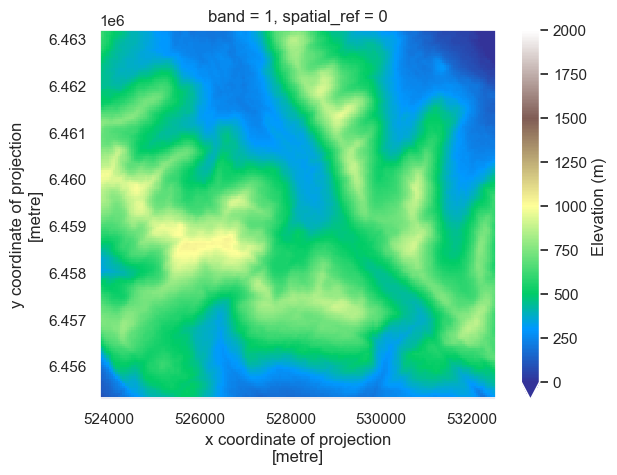

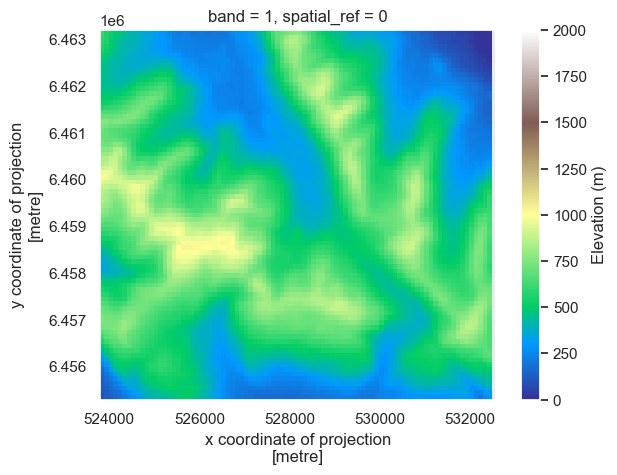

In [35]:
dem_50m.squeeze().plot(cmap='terrain', vmin=0, vmax=2000, cbar_kwargs={'label': 'Elevation (m)'})
plt.show()
dem_100m.squeeze().plot(cmap='terrain', vmin=0, vmax=2000, cbar_kwargs={'label': 'Elevation (m)'})

Okay, we are finished with the DEM filling and resampling. Let's move on to the wind data. 

I will do that in the next script, `6c_prepare_wind_fields_wind_ninja.ipynb`